Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
import joblib

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


Generating dataset

In [2]:
def generate_rankine_dataset(n_samples=1000):
    np.random.seed(42)
    data = []

    for i in range(n_samples):
        boiler_pressure = np.random.uniform(30, 170)
        boiler_temp = np.random.uniform(400, 600)
        condenser_pressure = np.random.uniform(0.04, 0.20)
        turbine_eff = np.random.uniform(0.75, 0.95)
        pump_eff = np.random.uniform(0.70, 0.95)
        mass_flow = np.random.uniform(50, 500)

        pressure_ratio = boiler_pressure / condenser_pressure

        T_high = boiler_temp + 273.15
        T_low = 40 + 273.15
        carnot = 1 - (T_low / T_high)
        base_eff = carnot * 0.6

        pressure_factor = 0.05 * np.log10(pressure_ratio)
        temp_factor = (boiler_temp - 400) / 200 * 0.08
        comp_factor = (turbine_eff - 0.75) * 0.3 + (pump_eff - 0.70) * 0.1
        noise = np.random.normal(0, 0.02)

        eff = (base_eff + pressure_factor + temp_factor + comp_factor + noise)
        eff = np.clip(eff * 100, 15, 50)

        h_in = 3000 + (boiler_temp - 400) * 2
        h_out = 2000 + (40 - condenser_pressure * 100) * 0.5
        power = mass_flow * (h_in - h_out) * turbine_eff / 1000

        data.append({
            'boiler_pressure_bar': boiler_pressure,
            'boiler_temp_C': boiler_temp,
            'condenser_pressure_bar': condenser_pressure,
            'turbine_efficiency': turbine_eff,
            'pump_efficiency': pump_eff,
            'mass_flow_rate_kg_s': mass_flow,
            'power_output_MW': power,
            'cycle_efficiency_percent': eff
        })

    df = pd.DataFrame(data)
    print(f" Dataset generated: {df.shape}")
    return df


In [3]:
dataset = generate_rankine_dataset(1000)
dataset.to_csv("rankine_cycle_dataset.csv", index=False)
dataset.head()


 Dataset generated: (1000, 8)


,boiler_pressure_bar,boiler_temp_C,condenser_pressure_bar,turbine_efficiency,pump_efficiency,mass_flow_rate_kg_s,power_output_MW,cycle_efficiency_percent
0,82.435617,590.142861,0.157119,0.869732,0.739005,120.197534,143.024991,50.0
1,32.881829,593.981970,0.173191,0.792468,0.745456,132.532029,144.583142,50.0
2,72.593914,504.951286,0.109111,0.808246,0.852963,112.772237,108.954133,50.0
3,93.849798,557.035192,0.071948,0.852847,0.848104,70.902686,78.468848,50.0
4,115.056279,434.104825,0.050408,0.939777,0.941408,413.778807,408.586734,50.0


Features that need to be trained


In [4]:
features = ['boiler_pressure_bar','boiler_temp_C','condenser_pressure_bar',
            'turbine_efficiency','pump_efficiency','mass_flow_rate_kg_s']

X = dataset[features]
y = dataset['cycle_efficiency_percent']

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestRegressor(n_estimators=120, max_depth=15, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(" Model Training Complete")
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))


 Model Training Complete
R² Score: -2.619424324073059
RMSE: 0.2405863505951752
MAE: 0.07703357397779247


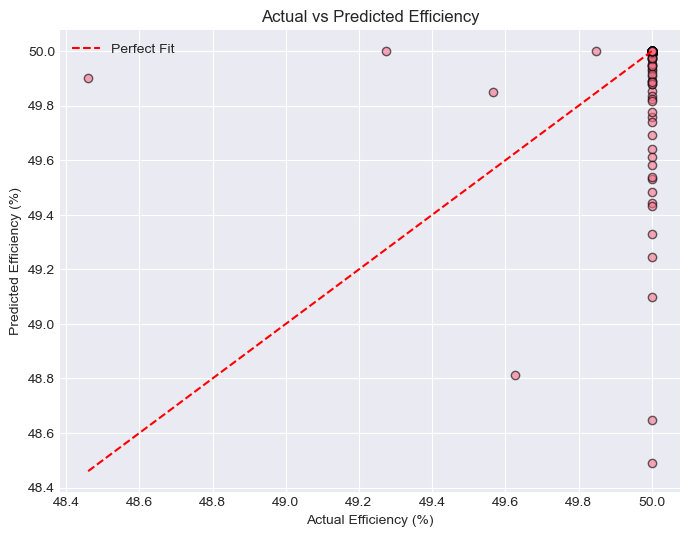

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         "r--", label="Perfect Fit")
plt.xlabel("Actual Efficiency (%)")
plt.ylabel("Predicted Efficiency (%)")
plt.title("Actual vs Predicted Efficiency")
plt.legend()
plt.show()


T-Sn diagram of rankine cycle

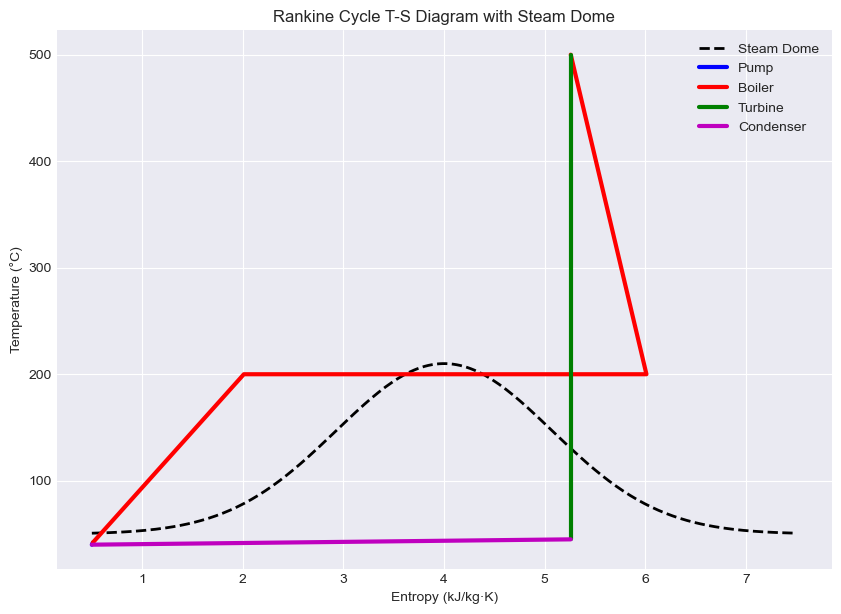

In [6]:
def plot_ts_diagram(boiler_temp=500):
    # --- Rankine cycle state points ---
    s1, T1 = 0.5, 40          # Condenser outlet
    s2, T2 = 0.51, 42         # Pump outlet
    T3 = boiler_temp          # Boiler outlet (superheated)
    s3 = s2 + (T3 - T2) * 0.006 + 2  # Approx. entropy rise

    s4, T4 = s3, 45           # Turbine outlet (isentropic approx.)

    n = 50

    # Pump 1 → 2
    s_12 = np.linspace(s1, s2, n)
    T_12 = np.linspace(T1, T2, n)

    # Boiler 2 → 3 (heating + evap + superheat)
    T_sat = 200

    s_23a = np.linspace(s2, s2 + 1.5, n//3)
    T_23a = np.linspace(T2, T_sat, n//3)

    s_23b = np.linspace(s_23a[-1], s_23a[-1] + 4, n//3)
    T_23b = np.full(n//3, T_sat)

    s_23c = np.linspace(s_23b[-1], s3, n//3)
    T_23c = np.linspace(T_sat, T3, n//3)

    s_23 = np.concatenate([s_23a, s_23b, s_23c])
    T_23 = np.concatenate([T_23a, T_23b, T_23c])

    # Turbine 3 → 4
    s_34 = np.linspace(s3, s4, n)
    T_34 = np.linspace(T3, T4, n)

    # Condenser 4 → 1
    s_41 = np.linspace(s4, s1, n)
    T_41 = np.linspace(T4, T1, n)

    # --- Steam Dome (saturation curve) ---
    s_dome = np.linspace(0.5, 7.5, 200)
    T_dome = 50 + 160 * np.exp(-(s_dome - 4)**2 / 2.3)  # Gaussian bell shape

    # --- Plotting ---
    plt.figure(figsize=(10, 7))

    # Dome
    plt.plot(s_dome, T_dome, 'k--', linewidth=2, label="Steam Dome")

    # Rankine cycle processes
    plt.plot(s_12, T_12, 'b', lw=3, label="Pump")
    plt.plot(s_23, T_23, 'r', lw=3, label="Boiler")
    plt.plot(s_34, T_34, 'g', lw=3, label="Turbine")
    plt.plot(s_41, T_41, 'm', lw=3, label="Condenser")

    plt.xlabel("Entropy (kJ/kg·K)")
    plt.ylabel("Temperature (°C)")
    plt.title("Rankine Cycle T-S Diagram with Steam Dome")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_ts_diagram()


Depency of effieciency on various thing

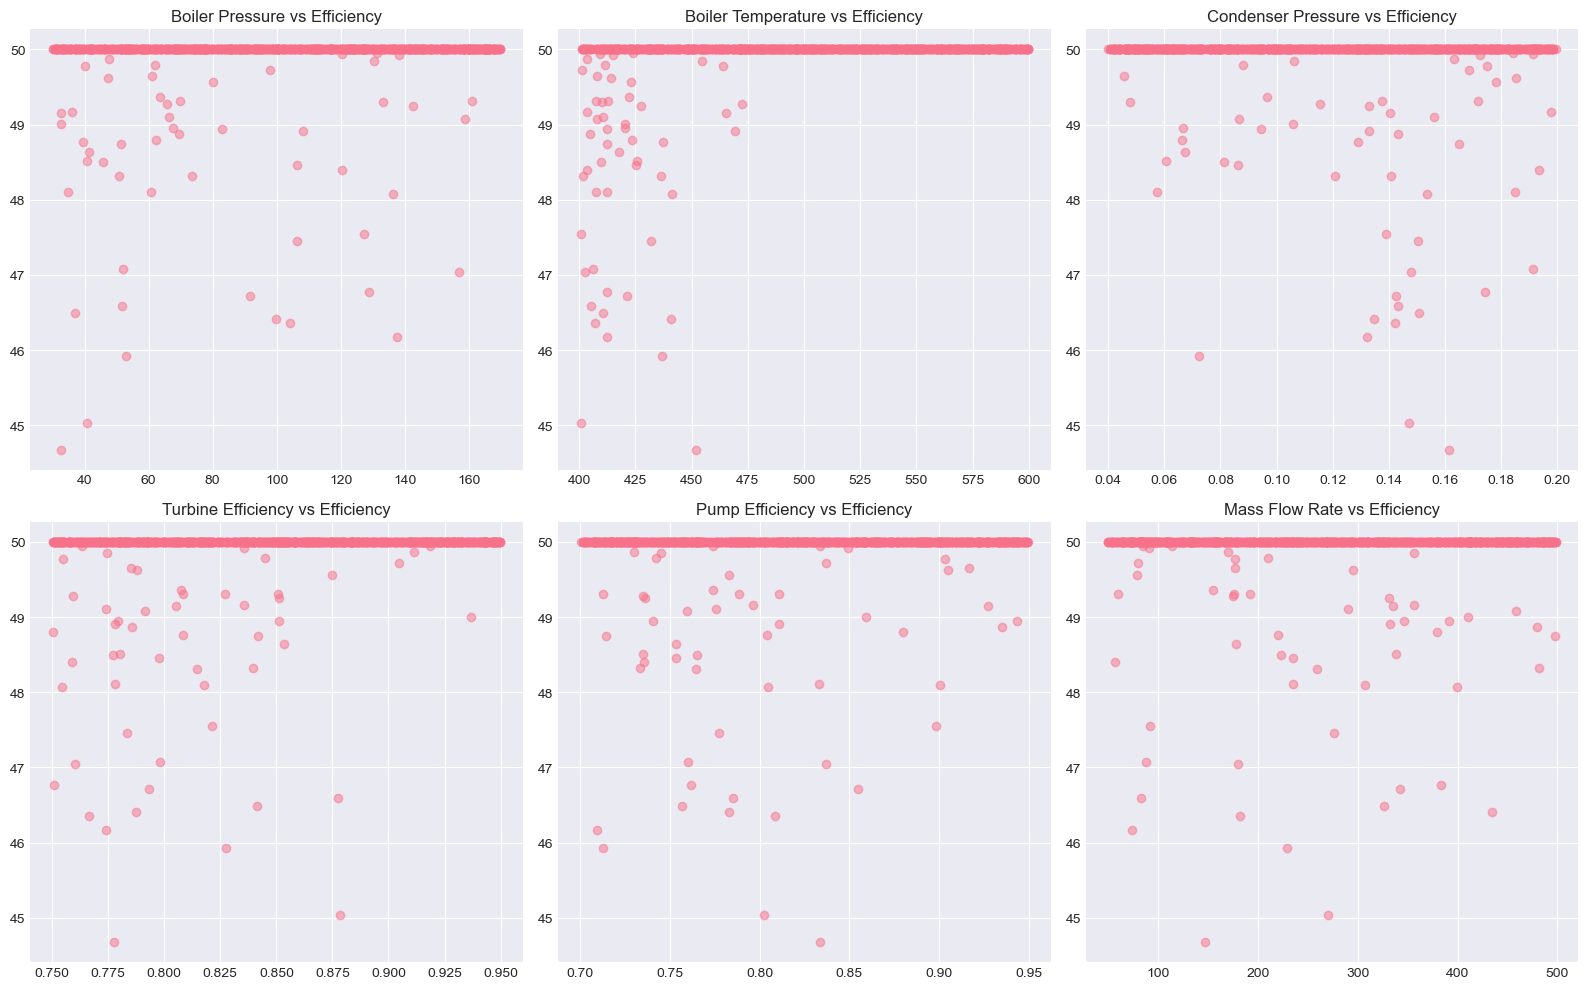

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

params = [
    ('boiler_pressure_bar', 'Boiler Pressure'),
    ('boiler_temp_C', 'Boiler Temperature'),
    ('condenser_pressure_bar', 'Condenser Pressure'),
    ('turbine_efficiency', 'Turbine Efficiency'),
    ('pump_efficiency', 'Pump Efficiency'),
    ('mass_flow_rate_kg_s', 'Mass Flow Rate')
]

for idx, (col, label) in enumerate(params):
    ax = axes[idx//3][idx%3]
    ax.scatter(dataset[col], dataset['cycle_efficiency_percent'], alpha=0.5)
    ax.set_title(f"{label} vs Efficiency")

plt.tight_layout()
plt.show()


Model saving

In [8]:
joblib.dump({"model": model, "scaler": scaler}, "rankine_model.pkl")
print(" Model saved successfully!")


 Model saved successfully!


Predicting the efficiency

In [9]:
def predict_eff(boiler_pressure, boiler_temp, condenser_pressure, turb_eff, pump_eff, mass_flow):
    X_new = np.array([[boiler_pressure, boiler_temp, condenser_pressure, turb_eff, pump_eff, mass_flow]])
    X_scaled = scaler.transform(X_new)
    return model.predict(X_scaled)[0]

predict_eff(200, 23, 0.8, 0.9, 0.88, 4)


c:\Users\Jainil\.continuum\1\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


48.011705998003514